Imports

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [35]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\Expression_Genes_DESeq_Motor_cortex.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\DEA_Genes_DESeq_Motor_cortex.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Clinical_Data_Gogliotti18.csv"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [36]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
expression_df.head()

,Gene,mCTX_Ctrl_1,mCTX_Ctrl_2,mCTX_Ctrl_3,mCTX_Ctrl_4,mCTX_Ctrl_5,mCTX_Ctrl_6,mCTX_Ctrl_7,mCTX_Ctrl_8,mCTX_RTT_1,mCTX_RTT_3,mCTX_RTT_4,mCTX_RTT_5,mCTX_RTT_6,mCTX_RTT_7
0,DDX11L2,403,73,84,83,315,343,32,371,132,170,339,268,119,132
1,WASH7P,648,541,797,428,1081,528,482,335,426,466,413,463,365,368
2,ENSG00000238009,2,4,4,11,8,0,1,8,4,6,0,3,0,8
3,ENSG00000268903,28,41,58,41,39,18,58,124,72,22,60,56,28,14
4,ENSG00000269981,25,20,41,48,20,3,17,89,60,18,70,112,28,28


DEA - Import

In [37]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,KANK4,329.711678,1.938965,0.250031,7.754905,8.840946e-15,5.964986e-11
1,TYRO3,9063.429748,-0.555228,0.070958,-7.824730,5.087482e-15,5.964986e-11
2,ABCC12,348.700018,-1.510354,0.206608,-7.310245,2.666554e-13,1.199416e-09
3,NLGN4Y,586.123446,8.227464,1.221865,6.733530,1.655956e-11,5.586369e-08
4,ZNF257,398.174897,1.137053,0.175065,6.495015,8.302523e-11,2.240685e-07


Volcano plot

Classification
Non-significant    11282
Up-regulated        1120
Down-regulated      1092
Name: count, dtype: int64
2212
Total tes:
19064


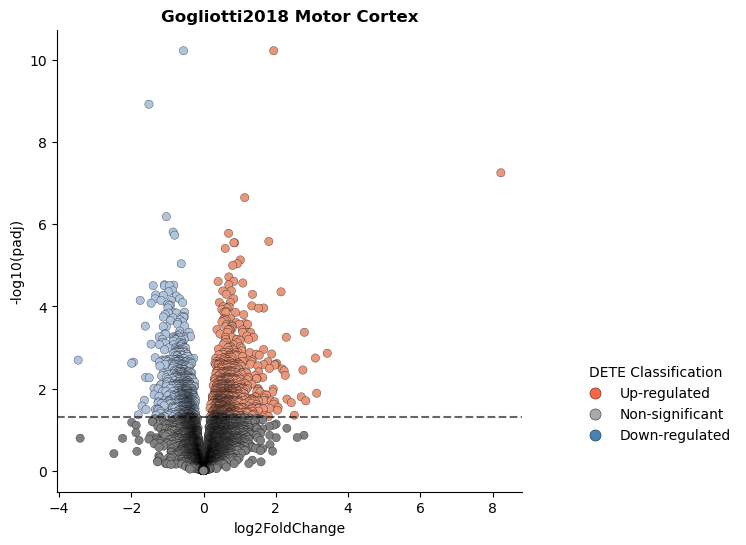

In [38]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Gogliotti2018 Motor Cortex', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['Gene'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['Gene'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['Gene'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['Gene'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['Gene'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DETE Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)
    

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    subset = dea_df[dea_df['Classification'] != 'Non-significant']
    print(len(subset))
    print('Total tes:')
    print(len(expression_df))

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False)
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [42]:
# Variables
genes = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)
clinical_data = pd.read_csv(CLINICAL_DATA)
clinical_data = clinical_data[clinical_data['Brain_Region'] == 'Motor Cortex']
clinical_data = clinical_data[clinical_data['MECP2_Mutation'].isin(['R270X', 'R255X', 'None (WT)'])]

print(expression_df)
# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

filtered_samples = clinical_data['Sample_Name'].tolist()
print(clinical_data[['Sample_Name', 'Sample_ID']])
log2cpm_df = log2cpm_df[filtered_samples]

# Process clinical data
clinical_data = clinical_data[['Sample_Name', 'Condition', 'Sample_ID', 'MECP2_Mutation']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample_Name', how = 'left')
pca_df = pca_df[pca_df['MECP2_Mutation'] != 'R168X']
pca_df = pca_df[pca_df['MECP2_Mutation'] != 'Negative']


pca_df




                  Gene  mCTX_Ctrl_1  mCTX_Ctrl_2  mCTX_Ctrl_3  mCTX_Ctrl_4  \
0              DDX11L2          403           73           84           83   
1               WASH7P          648          541          797          428   
2      ENSG00000238009            2            4            4           11   
3      ENSG00000268903           28           41           58           41   
4      ENSG00000269981           25           20           41           48   
...                ...          ...          ...          ...          ...   
19059           MT-ND5         2615         1934          957         3277   
19060           MT-ND6          813          441          264         1086   
19061            MT-TE            1            0            0            4   
19062           MT-CYB         1472         1084          522         1684   
19063            MT-TP            9            8            7            8   

       mCTX_Ctrl_5  mCTX_Ctrl_6  mCTX_Ctrl_7  mCTX_Ctrl_8  mCTX

,Sample_Name,PC1,PC2,Condition,Sample_ID,MECP2_Mutation
0,mCTX_Ctrl_1,37.355876,-17.667550,Ctrl,3325-CMN-1,None (WT)
1,mCTX_Ctrl_2,98.161501,0.964235,Ctrl,3325-CMN-2,None (WT)
2,mCTX_Ctrl_3,-1.278336,50.118137,Ctrl,3325-CMN-3,None (WT)
3,mCTX_Ctrl_4,74.050926,30.940123,Ctrl,3325-CMN-4,None (WT)
4,mCTX_Ctrl_5,15.321420,0.769899,Ctrl,3325-CMN-5,None (WT)
5,mCTX_Ctrl_6,67.701569,30.342948,Ctrl,3325-CMN-6,None (WT)
6,mCTX_Ctrl_7,61.362804,-24.494765,Ctrl,3325-CMN-7,None (WT)
7,mCTX_Ctrl_8,-14.522287,30.420773,Ctrl,3325-CMN-8,None (WT)
8,mCTX_RTT_1,-54.707685,102.506373,RTT,3325-CMN-9,R255X
9,mCTX_RTT_3,7.538444,-67.933913,RTT,3325-CMN-11,R255X


PCA - Graph

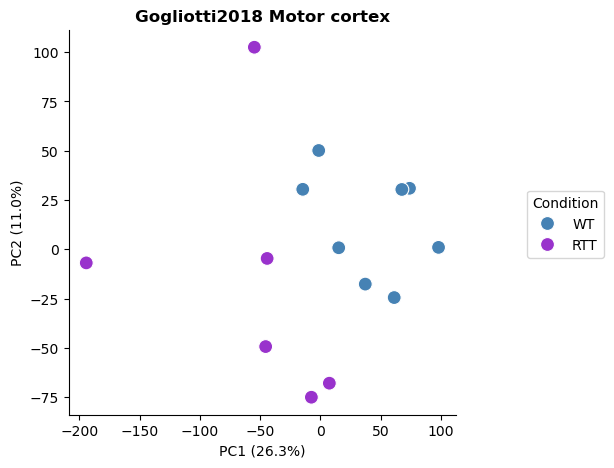

In [43]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'RTT' : 'darkorchid'}

pca_df['Condition'] = pca_df['Condition'].replace({'Ctrl' : 'WT'})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Gogliotti2018 Motor cortex", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

In [41]:
# Assemble the new table
log2cpm_df.insert(0, 'Gene', genes)
goi_df = log2cpm_df[log2cpm_df['Gene'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'Gene', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'RTT' : 'tomato',
                   'Ctrl' : 'steelblue'}

sns.boxplot(data = long_df, x = 'Gene', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - Genes - Motor cortex', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Genes')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)



TypeError: only list-like objects are allowed to be passed to isin(), you passed a `NoneType`